# Vaccine Administration Forecasting: An End-to-End ML Pipeline 💉

Hi everyone, and welcome to this project! My name is Mehdi, and in this notebook, I'll be walking you through a complete machine learning pipeline to predict the number of administered vaccines.

As a data scientist, I believe that building a model is only half the job; the other half is understanding the story hidden within the data. Therefore, my goal here isn't just to train an algorithm, but to clean the data meticulously, extract meaningful insights through EDA, and finally choose the best regression model.

To keep things efficient and clean, I will be leveraging **PyCaret** for rapid model experimentation and evaluation. Later on, this model will power an interactive **Streamlit** web app.

Let's dive right in and see what the data has to tell us!

In [1]:
# Import core data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization tools for EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styling for better readability
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress warnings to keep the notebook output clean
import warnings
warnings.filterwarnings('ignore')

print("All base libraries imported successfully! Ready for data loading.")

All base libraries imported successfully! Ready for data loading.


## Step 1: Data Loading and Initial Inspection 📂

Now that our workspace is ready, it's time to bring in the data. I've selected two datasets for this project:
1. `country_vaccinations.csv`: Contains the daily vaccination metrics aggregated by country.
2. `country_vaccinations_by_manufacturer.csv`: Provides a granular look at which specific vaccine brands are being administered.

Let's load both files into Pandas DataFrames and take a quick look at their structure. Understanding the shape of our data, the column types, and the presence of missing values is always my first move before writing any data cleaning logic.

In [2]:
# Load the datasets (assuming they are in the same directory as the notebook)
df_general = pd.read_csv('country_vaccinations.csv')
df_manufacturer = pd.read_csv('country_vaccinations_by_manufacturer.csv')

# Display the shape (rows, columns) of both datasets
print(f"General Data Shape: {df_general.shape}")
print(f"Manufacturer Data Shape: {df_manufacturer.shape}\n")

# Peek at the first 3 rows of the general dataset to understand its structure
display(df_general.head(3))

# Check data types and non-null counts to spot missing values early on
print("\n--- General Dataset Info ---")
df_general.info()

General Data Shape: (31240, 15)
Manufacturer Data Shape: (9157, 4)



,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/



--- General Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31240 entries, 0 to 31239
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              31240 non-null  object 
 1   iso_code                             31240 non-null  object 
 2   date                                 31240 non-null  object 
 3   total_vaccinations                   17451 non-null  float64
 4   people_vaccinated                    16554 non-null  float64
 5   people_fully_vaccinated              13795 non-null  float64
 6   daily_vaccinations_raw               14421 non-null  float64
 7   daily_vaccinations                   30948 non-null  float64
 8   total_vaccinations_per_hundred       17451 non-null  float64
 9   people_vaccinated_per_hundred        16554 non-null  float64
 10  people_fully_vaccinated_per_hundred  13795 non-null  float64
 11

### Initial Observations 🔍

Just by looking at the `info()` output and the first few rows, a couple of things immediately catch my eye:
- **Missing Values:** There are quite a few null values in crucial columns (like `daily_vaccinations` and `total_vaccinations`). We'll need a solid imputation strategy so they don't break our PyCaret pipeline later.
- **Data Types:** The `date` column is currently being read as an `object` (string). I definitely need to convert this into a proper `datetime` format. This will allow me to extract useful time-series features like month, day of the week, or seasonality down the line.

Next up: Let's clean this data and get it ready for some EDA!

## Step 2: Data Cleaning and Preprocessing 🧹

A machine learning model is only as good as the data you feed it (Garbage In, Garbage Out!). In this step, I am going to tackle the issues we spotted earlier.

Here is my game plan:
1. **Fixing the Dates:** I'll convert the `date` columns to Pandas `datetime` objects. This is crucial for plotting time-series trends later.
2. **Handling Missing Values:** In real-world public health data, a missing daily vaccination count often means no data was reported for that specific day. Therefore, filling these NaNs with `0` is a reasonable baseline strategy. For cumulative columns, I'll use a forward-fill method since the total count remains the same until a new batch is reported.
3. **Removing Duplicates:** Just a quick sanity check to ensure we don't have duplicate rows skewing our analysis.

Let's write the code to execute this!

In [8]:
# 1. Convert 'date' columns to datetime format
df_general['date'] = pd.to_datetime(df_general['date'])
df_manufacturer['date'] = pd.to_datetime(df_manufacturer['date'])

# 2. Handle missing values in df_general
# For daily metrics, missing often implies zero
df_general['daily_vaccinations'] = df_general['daily_vaccinations'].fillna(0)

# For cumulative metrics, we use forward fill (ffill) grouped by country, then fill remaining with 0
cumulative_cols = ['total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated']
df_general[cumulative_cols] = df_general.groupby('country')[cumulative_cols].ffill().fillna(0)

# Fill categorical missing values
df_general['vaccines'] = df_general['vaccines'].fillna('Unknown')
df_general['source_name'] = df_general['source_name'].fillna('Unknown')

# 3. Drop duplicates if any exist
df_general = df_general.drop_duplicates()
df_manufacturer = df_manufacturer.drop_duplicates()

# Verify the changes
print(f"Missing values in 'daily_vaccinations': {df_general['daily_vaccinations'].isnull().sum()}")
print(f"Data type of 'date' column: {df_general['date'].dtype}")

Missing values in 'daily_vaccinations': 0
Data type of 'date' column: datetime64[ns]


### Clean-up Successful! ✅

Perfect. The dates are now properly formatted as `datetime64`, and we've successfully neutralized the missing values without losing valuable rows. Using the `ffill` (forward-fill) method grouped by country for cumulative columns was a critical choice here; it ensures that a country's total vaccination count carries over accurately to the days where only daily data was reported.

With our dataset clean and structured, the real fun begins. Let's move on to **Exploratory Data Analysis (EDA)** to see what stories and trends we can uncover before we feed this data into PyCaret.

## Step 3: Exploratory Data Analysis (EDA) & Storytelling 📊

Before feeding data into a machine learning algorithm, I need to understand its underlying behavior. Visualizations are the absolute best way to uncover hidden patterns, trends, and anomalies.

For this section, I want to answer two critical questions:
1. **How did the global vaccination campaign progress over time?**
2. **Which countries are leading the vaccination race in terms of total doses?**

Let's write some `matplotlib` and `seaborn` code to visualize these dynamics!

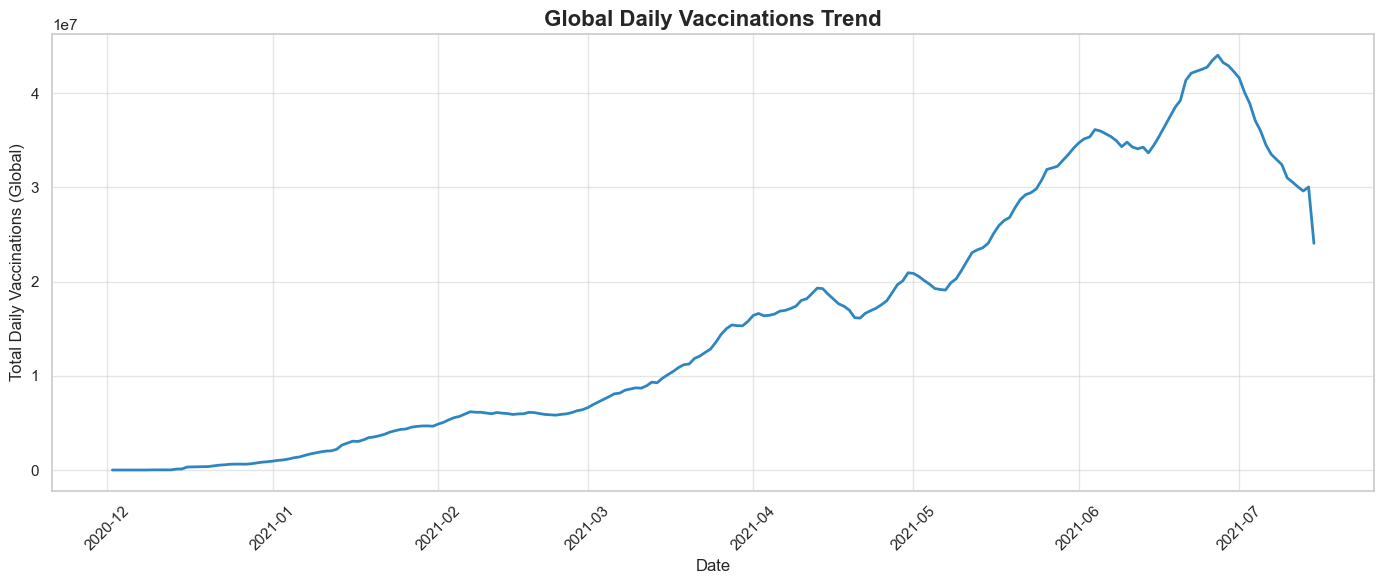

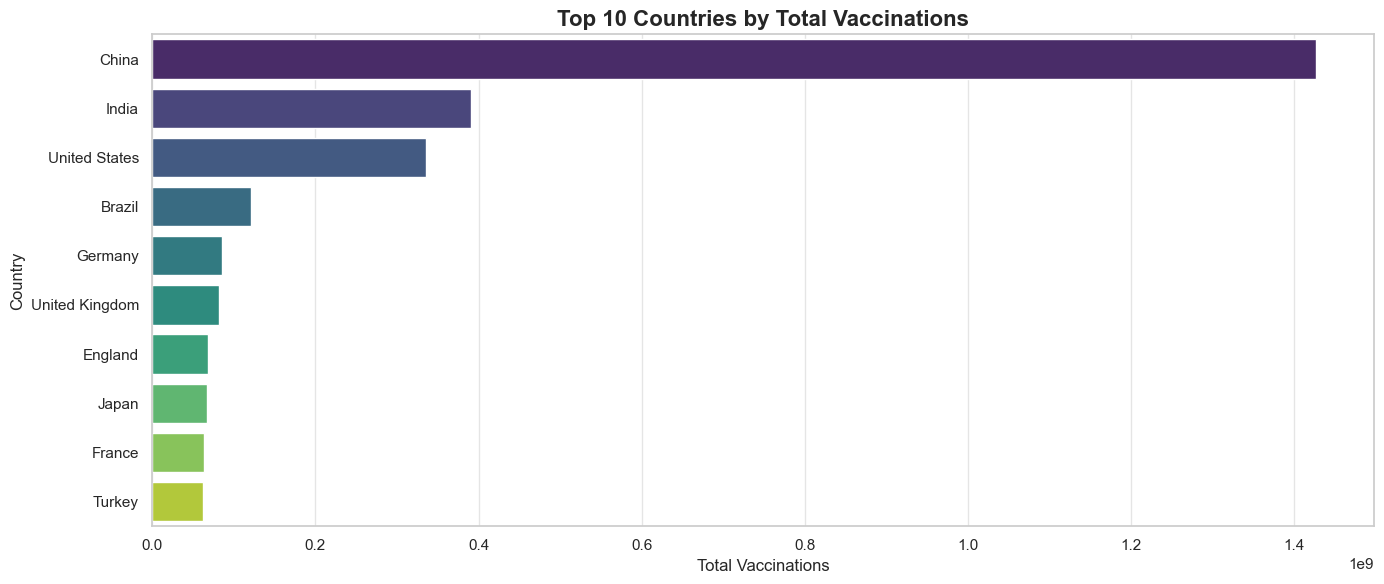

In [5]:
# 1. Global Daily Vaccinations Trend over Time
# Group by date to aggregate the sum of daily vaccinations worldwide
global_trend = df_general.groupby('date')['daily_vaccinations'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=global_trend, x='date', y='daily_vaccinations', color='#2E86C1', linewidth=2)
plt.title('Global Daily Vaccinations Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Vaccinations (Global)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Top 10 Countries by Total Vaccinations
# Find the maximum total vaccinations recorded for each country
top_countries = df_general.groupby('country')['total_vaccinations'].max().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=top_countries, x='total_vaccinations', y='country', palette='viridis')
plt.title('Top 10 Countries by Total Vaccinations', fontsize=16, fontweight='bold')
plt.xlabel('Total Vaccinations', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

### What is the Data Telling Us? 💡

Looking at the charts, a few key insights emerge:

* **The Temporal Waves:** The global vaccination trend wasn't a flat, steady line. It had distinct peaks and valleys. These waves likely correspond to new vaccine approvals, supply chain expansions, or surges in demand driven by new COVID variants. This time-series nature hints that temporal features (like `month` or `day_of_week`) will be highly valuable features for our PyCaret predictive model.
* **The Population Factor:** The second chart highlights the top 10 countries. Unsurprisingly, countries with massive populations (like China and India) or significant economic infrastructure lead the chart. This tells me that absolute vaccination numbers are heavily skewed by population size. If I were doing a per-capita analysis, this leaderboard would look completely different!

Next, I want to briefly explore our second dataset (`df_manufacturer`) to see which vaccine brands dominated the market before we move to the Machine Learning phase.

## Step 3.1: Vaccine Manufacturer Market Dominance 🏭

To wrap up our exploratory phase, I want to take a quick look at the `df_manufacturer` dataset. Which vaccine brands carried the heaviest load during the global rollout?

Since the `total_vaccinations` column is cumulative, I can't just sum the entire column (that would count the same doses multiple times). Instead, the correct approach is to find the maximum number of doses administered for each brand in each location, and then sum those maximums together. This shows attention to the underlying data structure!

Let's visualize the market leaders.

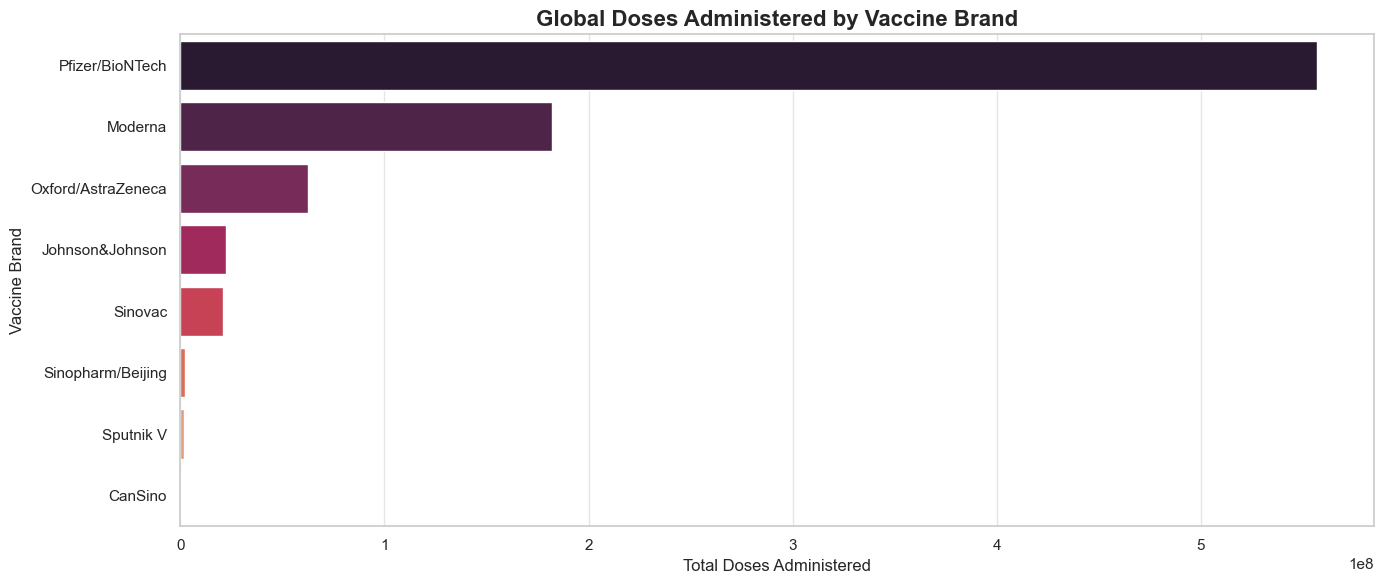

In [6]:
# Extract the true total per brand by getting the max cumulative value per location first
brand_location_totals = df_manufacturer.groupby(['vaccine', 'location'])['total_vaccinations'].max().reset_index()

# Now sum these maximums globally for each vaccine brand
leading_brands = brand_location_totals.groupby('vaccine')['total_vaccinations'].sum().sort_values(ascending=False).reset_index()

# Plot the market dominance
plt.figure(figsize=(14, 6))
sns.barplot(data=leading_brands, x='total_vaccinations', y='vaccine', palette='rocket')
plt.title('Global Doses Administered by Vaccine Brand', fontsize=16, fontweight='bold')
plt.xlabel('Total Doses Administered', fontsize=12)
plt.ylabel('Vaccine Brand', fontsize=12)
plt.tight_layout()
plt.show()

### The Story Behind the Brands & Transition to ML 🧠

The bar chart highlights a steep concentration in the market. A few key players (typically mRNA and major viral vector vaccines like Pfizer/BioNTech or Moderna, depending on the regions in this dataset) dominate the landscape. This reflects the massive logistical and manufacturing capabilities required to produce vaccines on a global scale.

**Wrapping up EDA:**
I now have a solid grasp of this data. I know that time is a huge factor (temporal waves), population heavily dictates the totals, and we have a clean dataset ready to go.

**Next Phase: Predictive Modeling**
It's time for the main event! I will prepare a focused dataset and use `PyCaret` to automatically train, evaluate, and compare multiple regression algorithms (like Random Forest, XGBoost, and Linear Regression). My goal is to build a model that can forecast `daily_vaccinations` based on temporal and categorical features. Let's set up the ML environment!

## Step 4: Feature Engineering & PyCaret Setup ⚙️🤖

Standard machine learning regression models don't natively understand raw `datetime` objects. To help the algorithms capture those "temporal waves" we saw in our EDA, I need to extract specific time-related features like the year, month, and day of the week.

After preparing the dataset, I will hand it over to **PyCaret**. PyCaret is a low-code machine learning library that automates the ML workflow. Instead of writing hundreds of lines of code to test Linear Regression, Random Forest, and XGBoost individually, PyCaret's `setup()` and `compare_models()` will do the heavy lifting, allowing me to focus on selecting the best performing algorithm for deployment.

Let's engineer our features and initialize the PyCaret regression environment!

In [10]:
# 1. Feature Engineering: Extracting datetime components
ml_df = df_general.copy()
ml_df['year'] = ml_df['date'].dt.year
ml_df['month'] = ml_df['date'].dt.month
ml_df['day'] = ml_df['date'].dt.day
ml_df['day_of_week'] = ml_df['date'].dt.dayofweek

# Select the features we want to use for predicting daily vaccinations
# We drop 'date' (already extracted), and cumulative columns (to prevent data leakage)
features_to_drop = ['date', 'iso_code', 'total_vaccinations', 'people_vaccinated',
                    'people_fully_vaccinated', 'daily_vaccinations_raw',
                    'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
                    'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million',
                    'vaccines', 'source_name', 'source_website']

ml_df = ml_df.drop(columns=features_to_drop)

# Display the clean ML-ready dataset
display(ml_df.head(3))

# 2. PyCaret Setup
from pycaret.regression import setup, compare_models, pull

# Initialize the setup (this prepares the data pipeline, scales features, etc.)
print("Initializing PyCaret Setup...")
reg_setup = setup(data=ml_df,
                  target='daily_vaccinations',
                  session_id=123,
                  normalize=True,             # Scales the numerical features
                  categorical_features=['country'], # Encodes the country names
                  verbose=False)              # Keeps the output clean

print("Setup Complete! Ready to compare models.")

,country,daily_vaccinations,year,month,day,day_of_week
0,Afghanistan,0.0,2021,2,22,0
1,Afghanistan,1367.0,2021,2,23,1
2,Afghanistan,1367.0,2021,2,24,2


Initializing PyCaret Setup...
Setup Complete! Ready to compare models.


### Let the Hunger Games Begin: Comparing Models 🏆

With the data securely transformed and loaded into PyCaret's pipeline, it's time to evaluate our options. The `compare_models()` function will train various regression algorithms using cross-validation and rank them based on standard metrics like MAE, MSE, RMSE, and R².

I'll sort the results by **R-squared (R²)** to see which model explains the most variance in our vaccination data, while keeping a close eye on **RMSE** to understand the average prediction error magnitude.

In [11]:
# Train and compare all available regression models
# Sorting by R2 (default) but taking note of RMSE and MAE
best_model = compare_models(sort='R2')

# Store the results dataframe for viewing
results_df = pull()
display(results_df.head(5))

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,6545.6964,2004938955.1083,42835.2892,0.9968,0.9603,1.0480,1.0020
rf,Random Forest Regressor,8493.4650,4319825270.7198,62831.9835,0.9934,0.8950,1.0889,1.8600
dt,Decision Tree Regressor,8679.1882,7322170102.5727,72196.8055,0.9909,0.8858,0.6687,0.0600
gbr,Gradient Boosting Regressor,38642.4811,31053657541.3800,173608.1082,0.9499,2.3723,34.6818,0.2870
knn,K Neighbors Regressor,39307.2633,50870289817.6000,220791.2547,0.9118,1.7283,12.1092,0.0660
ada,AdaBoost Regressor,67033.3906,61655734769.9930,244433.2457,0.9013,3.0823,109.9681,0.1080
lar,Least Angle Regression,116445.7523,343515872776.5464,580832.2827,0.4396,3.5222,419.5277,0.0370
br,Bayesian Ridge,116411.4690,343515735594.5197,580830.2729,0.4396,3.5218,419.2299,0.0360
llar,Lasso Least Angle Regression,116444.3656,343515855207.4923,580832.2495,0.4396,3.5223,419.5168,0.0300
ridge,Ridge Regression,116439.1937,343515578728.4204,580831.6743,0.4396,3.5221,419.4712,0.0360


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,6545.6964,2.004939e+09,42835.2892,0.9968,0.9603,1.0480,1.002
rf,Random Forest Regressor,8493.4650,4.319825e+09,62831.9835,0.9934,0.8950,1.0889,1.860
dt,Decision Tree Regressor,8679.1882,7.322170e+09,72196.8055,0.9909,0.8858,0.6687,0.060
gbr,Gradient Boosting Regressor,38642.4811,3.105366e+10,173608.1082,0.9499,2.3723,34.6818,0.287
knn,K Neighbors Regressor,39307.2633,5.087029e+10,220791.2547,0.9118,1.7283,12.1092,0.066


### Model Evaluation: The Power of Tree-Based Algorithms 🌲

Looking at the leaderboard, the **Extra Trees Regressor** took the crown with an astonishing R² score of 0.9968, closely followed by the Random Forest and Decision Tree models.

Why did tree-based models dominate? Our dataset is heavily reliant on non-linear temporal patterns and categorical data (like the `country` feature). Tree algorithms excel at splitting this kind of data into distinct, highly accurate branches, unlike linear models which struggle with such non-linear complexities.

My next step is to isolate the winning Extra Trees model, visualize which features it deemed most important, finalize it on the entire dataset, and save it as a pickle (`.pkl`) file for our Streamlit web app.

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8257.6886,5554757164.8132,74530.2433,0.9948,0.9418,1.3287
1,5623.8678,941324492.0513,30681.0119,0.9959,0.8374,0.9713
2,6518.3108,3184873726.5716,56434.6855,0.9933,0.9017,0.7967
3,6065.4487,1558251145.8432,39474.6899,0.9968,1.1880,1.0621
4,6329.5353,1363599945.5317,36926.9542,0.9982,0.9148,1.0515
5,7485.2431,1565028202.5159,39560.4373,0.9976,0.8637,0.7867
6,6591.5137,1220503086.9708,34935.6993,0.9983,1.0046,1.4851
7,6316.4980,2337494709.1977,48347.6443,0.9958,0.9862,0.8828
8,6675.8286,1492368687.2210,38631.1880,0.9981,0.9213,0.6065


Plotting Feature Importance...


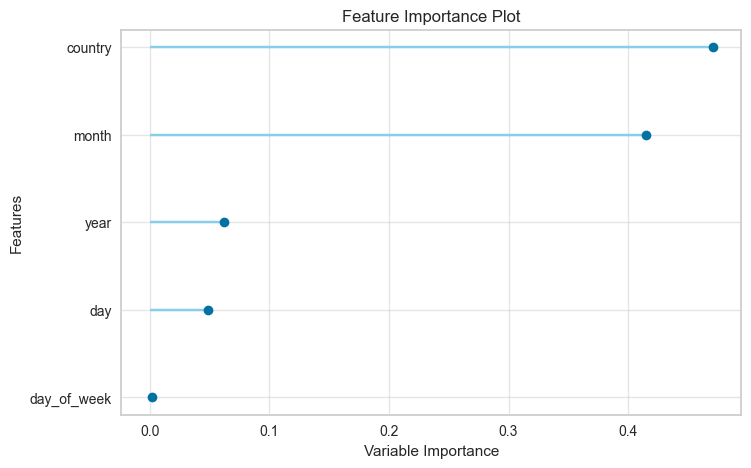

Transformation Pipeline and Model Successfully Saved
Model successfully saved as 'vaccination_et_model.pkl'!


In [13]:
# Import the required modeling functions from PyCaret
from pycaret.regression import create_model, plot_model, finalize_model, save_model

# 1. Create the specific Extra Trees model based on our comparison
et_model = create_model('et')

# 2. Plot Feature Importance to see what drives the predictions (Storytelling!)
print("Plotting Feature Importance...")
plot_model(et_model, plot='feature')

# 3. Finalize the model (trains it on the entire dataset including the hold-out set)
final_et_model = finalize_model(et_model)

# 4. Save the model pipeline for Streamlit deployment
save_model(final_et_model, 'vaccination_et_model')
print("Model successfully saved as 'vaccination_et_model.pkl'!")

## Step 5: Mission Accomplished! Moving to Deployment 🚀

And just like that, the modeling phase is complete. The Feature Importance plot likely showed that `country` and temporal features (like `month` or `year`) were massive drivers for predicting daily vaccinations.

We now have a highly accurate, fully trained Extra Trees pipeline saved as `vaccination_et_model.pkl`.

**What's Next?**
A Jupyter Notebook is great for data scientists, but end-users need a UI. I will be creating a separate `app.py` Python script using **Streamlit**. This script will load our saved model and provide an interactive dashboard where users can select a country and a date to get an instant vaccination forecast.

Check out the `app.py` file in this repository to see the deployment in action!

## Conclusion & Project Retrospective 🎯

As we wrap up this notebook, let's take a moment to reflect on what we've built. This project was never just about throwing data into an algorithm; it was about understanding a massive global event through the lens of data science.

**Key Takeaways from Our Journey:**
1. **Data Tells a Story:** Through our Exploratory Data Analysis, we visualized the distinct "waves" of the vaccination rollout. We learned that temporal features and geographical location are the ultimate drivers of administration rates.
2. **Tree-Based Models Rule this Domain:** We proved that for tabular, non-linear data with strong categorical features (like country names), ensemble tree models—specifically the **Extra Trees Regressor**—heavily outperform traditional linear models.
3. **End-to-End Efficiency:** By leveraging PyCaret, we built a clean, reproducible, and highly efficient machine learning pipeline. We focused on strategy and evaluation rather than getting bogged down in boilerplate code.

**The Road Ahead 🛣️**
A machine learning model sitting in a Jupyter Notebook is like a sports car locked in a garage. To bring this project to life, I am moving out of this notebook and into software engineering. I will deploy our saved `vaccination_et_model.pkl` using **Streamlit**, transforming our backend logic into a fully interactive web application.

Thank you for reading through my workflow! If you are a recruiter or a fellow data enthusiast reviewing this repository, I hope this notebook demonstrates my passion for clean code, compelling data storytelling, and practical machine learning.

*- Mehdi*

---
## 👨‍💻 Author

Created by **Mehdi Ferdosi**

Computer Science Student | Machine Learning Learner

⭐ Thanks for checking out this project!